# 03 - Comparación post-inferencia: persistencia vs EarthFormer vs CasCast

Usa este notebook **después** de correr inferencia desde la línea de comandos:

```bash
python scripts/run_model_inference.py --stage all --sample all --ddim-steps 20
python scripts/evaluate_predictions.py --sample all
```

La idea es evaluar exactamente los mismos casos con exactamente las mismas métricas que usamos para persistencia, pero ahora comparando predicciones reales de EarthFormer y CasCast cuando existan.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from course_utils.data import SAMPLE_FILES, get_paths, load_sample, split_sequence
from course_utils.evaluation import (
    available_prediction_models,
    evaluate_predictions,
    load_prediction_for_model,
    save_evaluation_tables,
)
from course_utils.plotting import plot_event_grid, plot_target_prediction_panel
from course_utils.palette import apply_course_style

apply_course_style()
paths = get_paths(PROJECT_ROOT)
print(f"Proyecto: {paths.root}")

Proyecto: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab


## 1. Ver qué predicciones existen

La comparación usa estas carpetas:

- `outputs/predictions/persistence/`
- `outputs/predictions/earthformer/`
- `outputs/predictions/cascast/`
- `outputs/predictions/model/`

In [2]:
availability = []
for name in SAMPLE_FILES:
    availability.append({
        "sample": name,
        "available_models": ", ".join(available_prediction_models(name, include_persistence=True, paths=paths)),
    })

pd.DataFrame(availability)

,sample,available_models
0,barranca_seq_20240426_2000_patch_04_rain_rate.npy,"persistence, earthformer, cascast"
1,barranca_seq_20240508_0600_patch_05_rain_rate.npy,persistence
2,barranca_seq_20240512_0800_patch_03_rain_rate.npy,persistence
3,guaviare_seq_20240329_0700_patch_05_rain_rate.npy,persistence
4,guaviare_seq_20240329_0800_patch_03_rain_rate.npy,persistence


## 2. Evaluación completa

Esta celda calcula:

- métricas continuas por lead time;
- métricas de evento por lead time y umbral;
- resumen por archivo;
- resumen global por modelo.

In [3]:
continuous_all, event_all, per_file, overall = evaluate_predictions(paths=paths)

output_dir = paths.root / "outputs" / "evaluation"
save_evaluation_tables(continuous_all, event_all, per_file, overall, output_dir)

print("Tablas guardadas en:", output_dir)
overall

Tablas guardadas en: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab/outputs/evaluation


,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_2_mean,CSI_5_mean,CSI_10_mean
1,earthformer,1.659013,0.247390,-0.089735,0.381944,0.446686,0.260869,0.141444,0.074342
2,persistence,1.717438,0.449517,0.056092,0.376623,0.544273,0.243252,0.100940,0.074848
0,cascast,1.830664,0.499277,0.063855,0.116888,0.150502,0.008399,0.000358,0.000000


## 3. Resumen por archivo

Busca casos donde un modelo tenga bajo RMSE pero bajo CSI a 10 mm/h. Esos son ejemplos buenos para discutir suavizado y pérdida de núcleos intensos.

In [4]:
per_file.sort_values(["sample", "RMSE_mean"])

,sample,model,RMSE_mean,MAE_mean,Bias_mean,Pearson_mean,CSI_0.5_mean,CSI_2_mean,CSI_5_mean,CSI_10_mean
1,barranca_seq_20240426_2000_patch_04_rain_rate.npy,earthformer,1.659013,0.247390,-0.089735,0.381944,0.446686,0.260869,0.141444,0.074342
2,barranca_seq_20240426_2000_patch_04_rain_rate.npy,cascast,1.830664,0.499277,0.063855,0.116888,0.150502,0.008399,0.000358,0.000000
0,barranca_seq_20240426_2000_patch_04_rain_rate.npy,persistence,2.171548,0.346029,-0.020286,0.261823,0.398552,0.250179,0.137261,0.087754
3,barranca_seq_20240508_0600_patch_05_rain_rate.npy,persistence,2.109822,0.692845,0.078865,0.531172,0.887441,0.520551,0.113525,0.120020
4,barranca_seq_20240512_0800_patch_03_rain_rate.npy,persistence,2.008800,0.237560,0.125580,0.276087,0.337051,0.123346,0.120790,0.099290
5,guaviare_seq_20240329_0700_patch_05_rain_rate.npy,persistence,1.523588,0.621125,0.068376,0.296114,0.523193,0.167601,0.093174,0.027039
6,guaviare_seq_20240329_0800_patch_03_rain_rate.npy,persistence,0.773435,0.350024,0.027926,0.517920,0.575129,0.154582,0.039947,0.040135


## 4. RMSE vs CSI intenso

Una comparación útil de fidelidad: a la izquierda está el error promedio, y arriba está la habilidad para lluvia intensa.

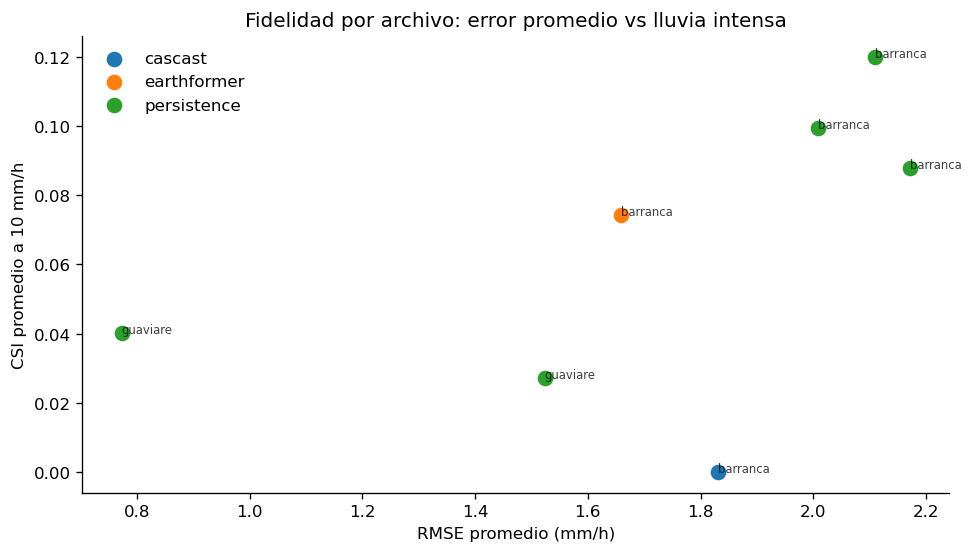

In [5]:
if per_file.empty or len(per_file["model"].unique()) == 1:
    print("Solo hay un modelo disponible. Corre inferencia de EarthFormer/CasCast para comparar.")
else:
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    for model_name, group in per_file.groupby("model"):
        ax.scatter(group["RMSE_mean"], group["CSI_10_mean"], s=70, label=model_name)
        for _, row in group.iterrows():
            ax.annotate(row["sample"].split("_seq_")[0], (row["RMSE_mean"], row["CSI_10_mean"]), fontsize=7, alpha=0.75)
    ax.set_xlabel("RMSE promedio (mm/h)")
    ax.set_ylabel("CSI promedio a 10 mm/h")
    ax.set_title("Fidelidad por archivo: error promedio vs lluvia intensa")
    ax.legend()
    plt.show()

## 5. Comparación visual en un caso

Cambia `sample_name` para mirar caso por caso. Si CasCast existe, debería aparecer junto a EarthFormer y persistencia.

Modelos disponibles: ['persistence', 'earthformer', 'cascast']


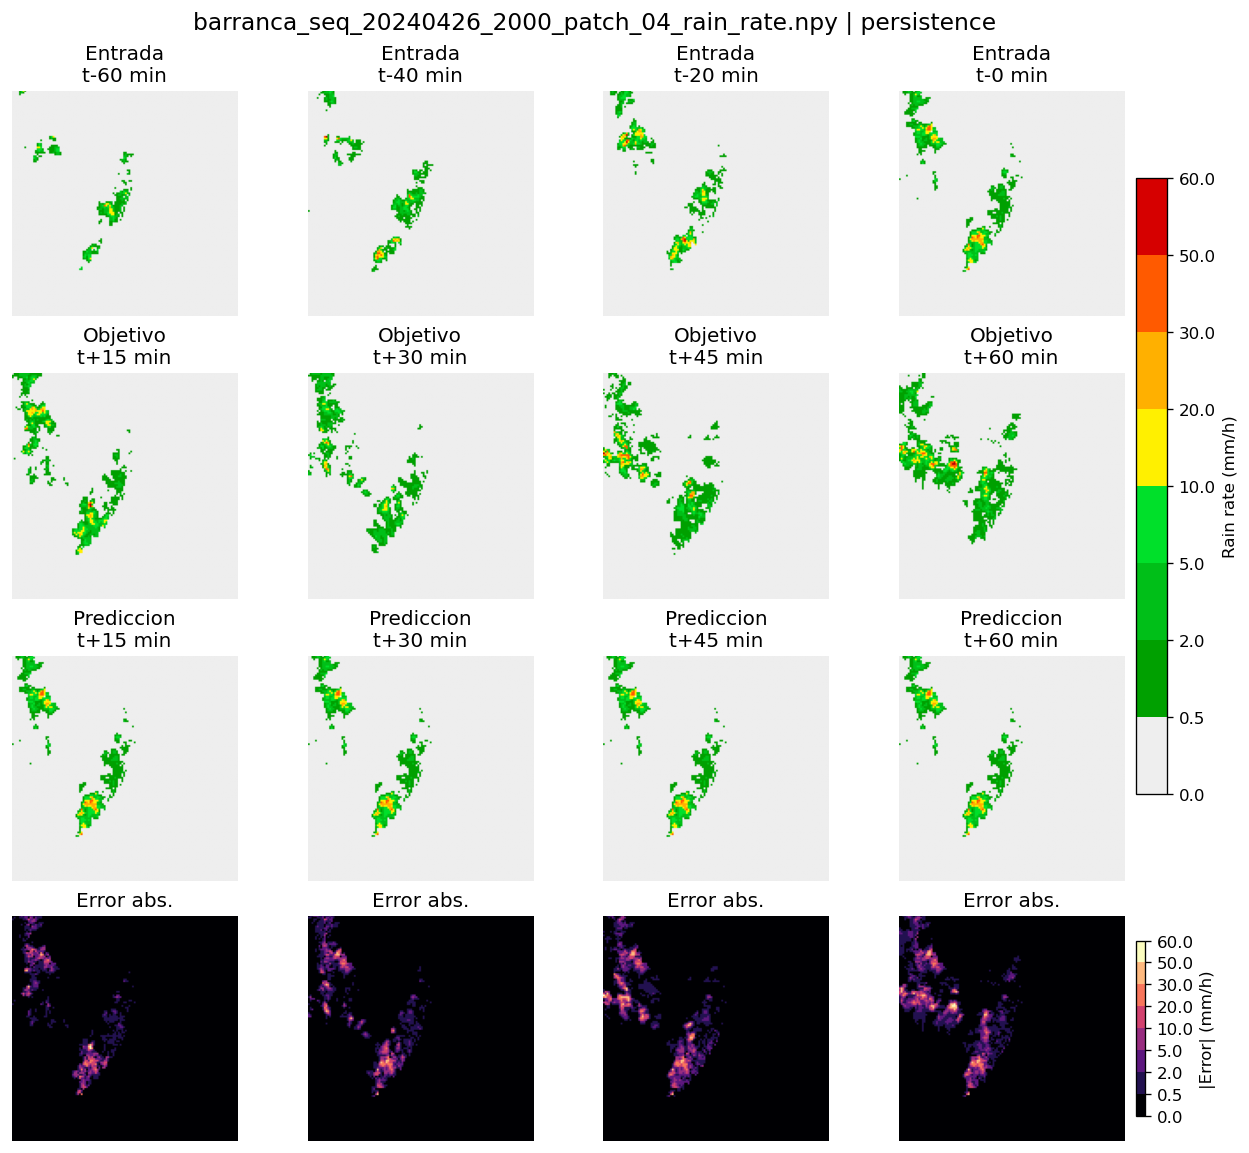

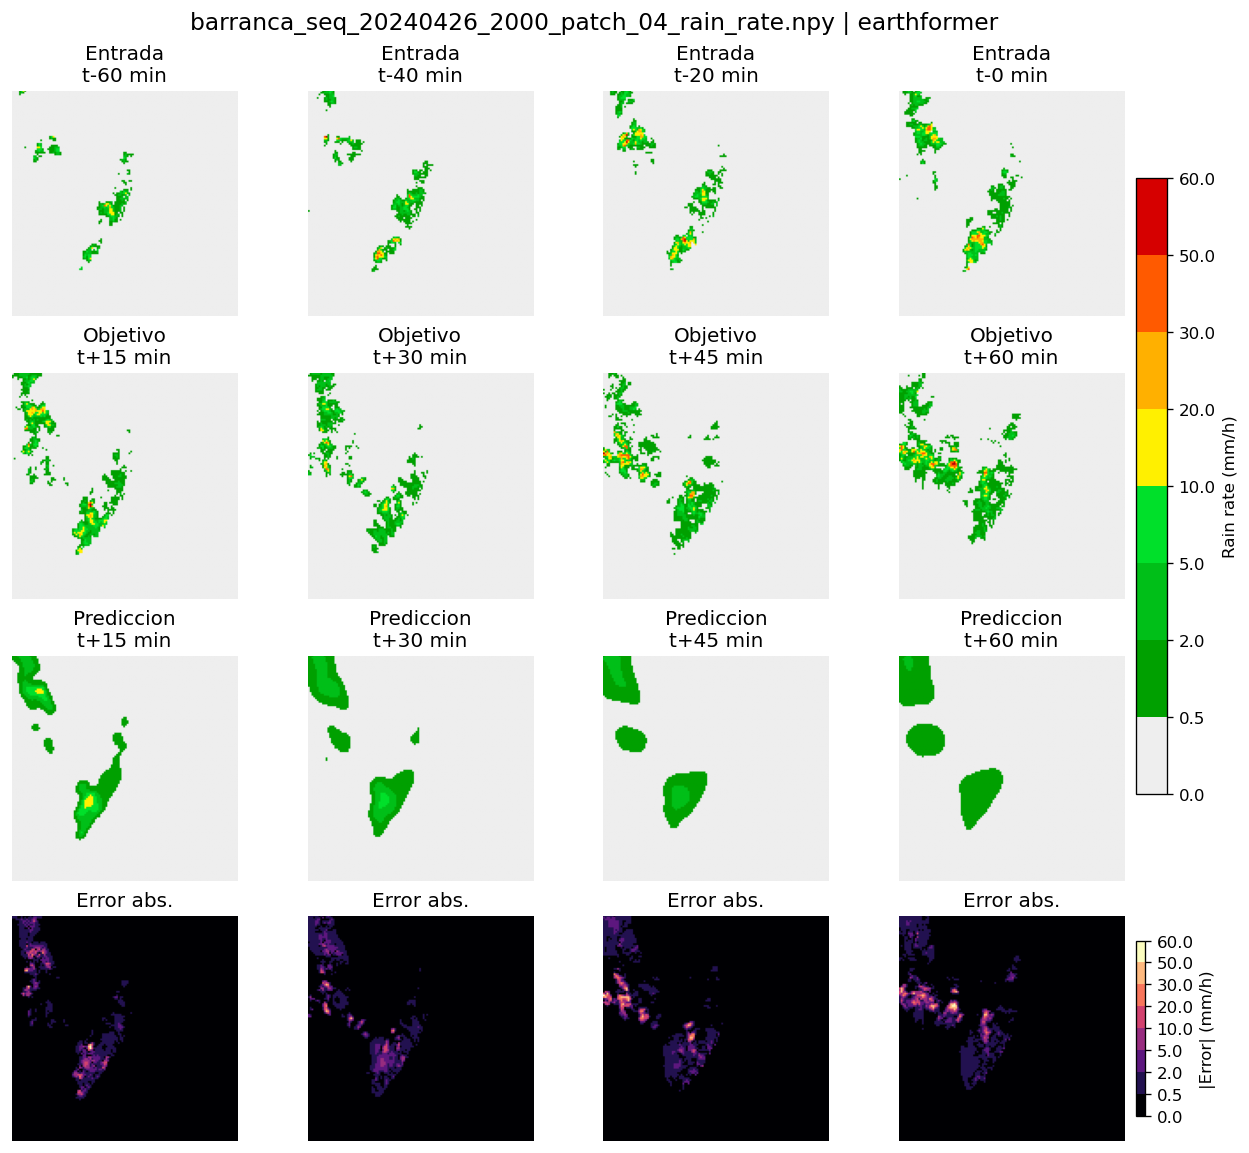

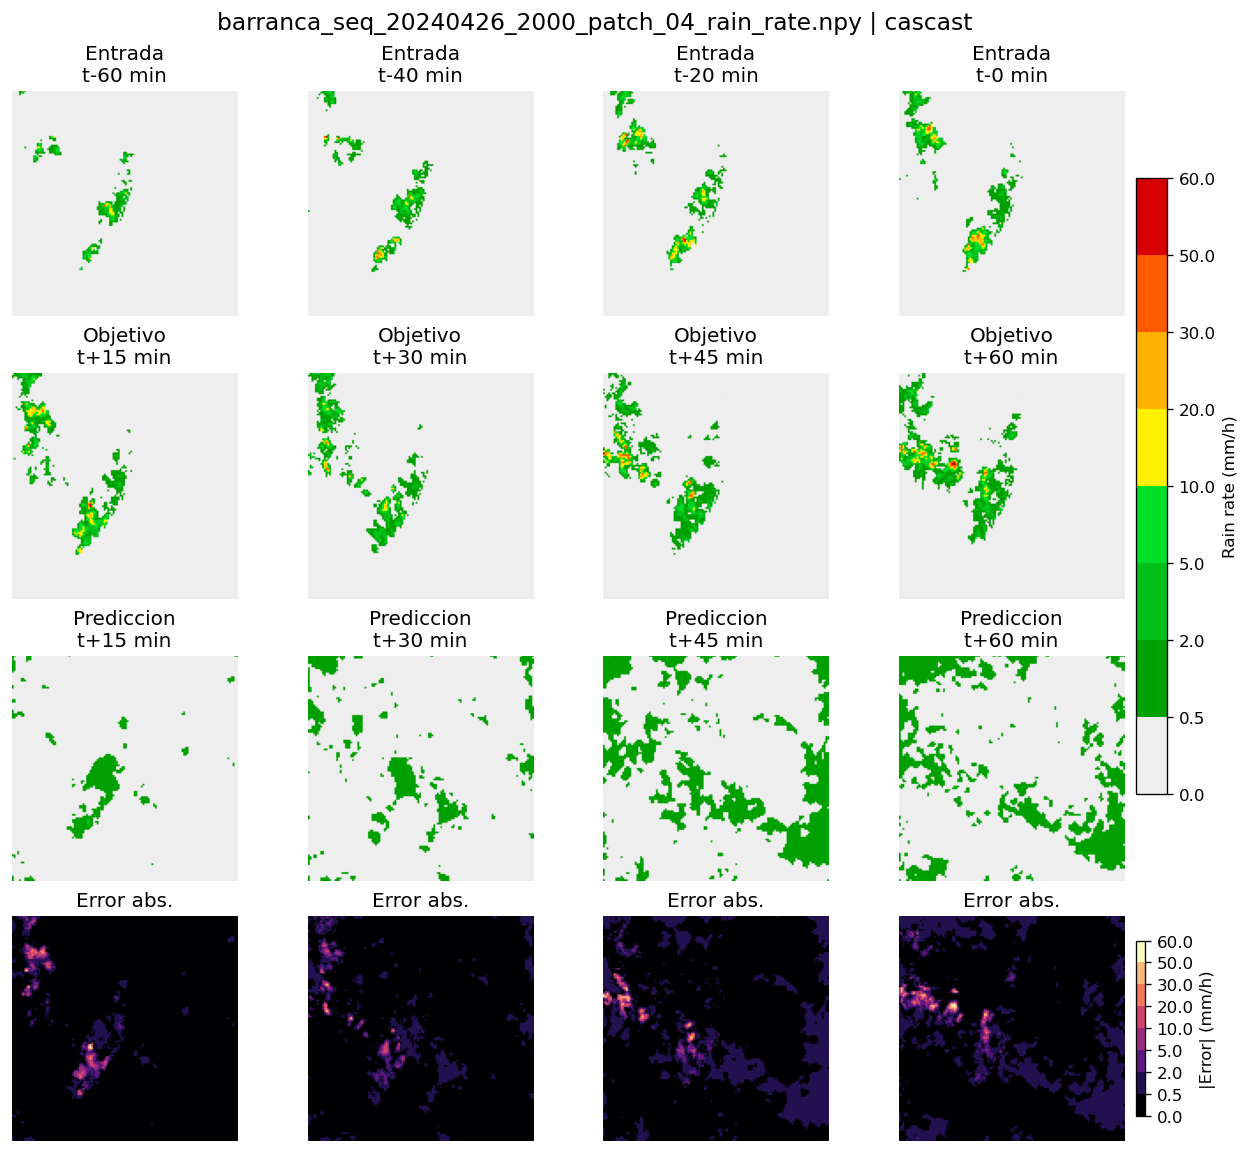

In [ ]:
sample_name = SAMPLE_FILES[0]
sequence = load_sample(sample_name, paths)
inputs, target = split_sequence(sequence)
models = available_prediction_models(sample_name, include_persistence=True, paths=paths)
print("Modelos disponibles:", models)

for model_name in models:
    pred = load_prediction_for_model(sample_name, inputs, model_name, paths)
    fig = plot_event_grid(inputs, target, pred, sample_name, model_name, lead_indices=(2, 5, 8, 11))
    plt.show()

## 6. Panel compacto modelo a modelo

Esta figura usa las filas como modelos y las columnas como tiempos de pronóstico.

In [ ]:
cases = []
for model_name in models:
    pred = load_prediction_for_model(sample_name, inputs, model_name, paths)
    cases.append({"label": model_name, "target": target, "prediction": pred})

fig = plot_target_prediction_panel(cases, title=f"Comparación por modelo: {sample_name}")
plt.show()

## 7. Preguntas para discusión

1. ¿EarthFormer reduce RMSE frente a persistencia?
2. ¿CasCast cambia CSI a 5 o 10 mm/h?
3. ¿Algún modelo parece más suave visualmente?
4. ¿Hay casos donde el modelo mejora lluvia ligera pero falla lluvia intensa?
5. ¿Qué modelo conservarías para una alerta de lluvia fuerte y por qué?